In [22]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [23]:
import importlib
import warnings
import numpy as np
from scipy.linalg import LinAlgWarning
from sklearn.exceptions import FitFailedWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2


In [24]:
# Ignore warning that might occur during grid search
warnings.filterwarnings("ignore", category=UserWarning, append=True)
warnings.filterwarnings("ignore", category=LinAlgWarning,append=True)
warnings.filterwarnings("ignore", category=FitFailedWarning, append=True)

In [25]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [26]:

param_grid_default = [
    # LINEAR: no gamma, no degree
    {
        "model__estimator__kernel": ["linear"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
    },

    # RBF: alpha + gamma
    {
        "model__estimator__kernel": ["rbf"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-4, 1, 6),
    },

    # POLY: alpha + gamma + degree
    {
        "model__estimator__kernel": ["poly"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-4, 0, 5),
        "model__estimator__degree": [2, 3],
    },

    # SIGMOID: alpha + gamma (range più stretto)
    {
        "model__estimator__kernel": ["sigmoid"],
        "model__estimator__alpha": np.logspace(-4, 2, 7),
        "model__estimator__gamma": np.logspace(-6, -1, 6),
    },
]

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(KernelRidge())),
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,min),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [27]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [28]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [29]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

In [30]:
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 161  splits: 5
Best params: {'model__estimator__alpha': np.float64(0.1), 'model__estimator__gamma': np.float64(1.0), 'model__estimator__kernel': 'rbf'}
Best score: -17.44827308654785
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=KernelRidge(alpha=np.float64(0.1),
                                                            gamma=np.float64(1.0),
                                                            kernel='rbf')))])


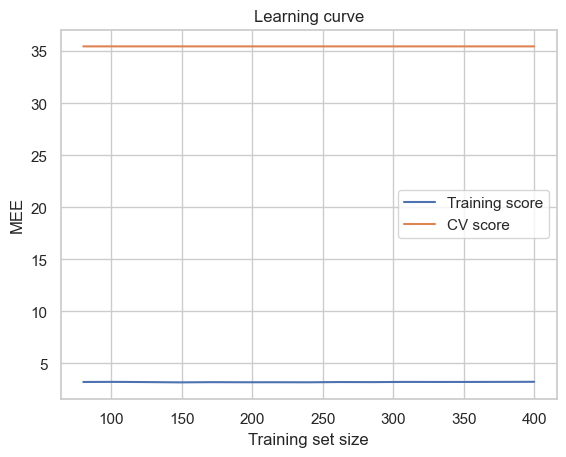

In [31]:
importlib.reload(cr)
cr.plot_learning_curve(best_model, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [32]:
from sklearn import clone

runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
kf_result = cr.kfold(runner, X_tr, y_tr, outer_cv,metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 16.9364
Validation mse       | 101.6272
Validation mae       | 7.5098
Validation rmse      | 10.0810
Validation r2        | 0.6500
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 17.2343
Validation mse       | 96.7836
Validation mae       | 7.6586
Validation rmse      | 9.8379
Validation r2        | 0.6805
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 17.2264
Validation mse       | 94.7815
Validation mae       | 7.6323
Validation rmse  

In [33]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -17.4483 ± 0.9174
Best CV func score: 17.4483 ± 0.9174


<h3>Nested Cross Validation</h3>

In [34]:
importlib.reload(cr)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv,metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 161  splits: 3
Best params: {'model__estimator__alpha': np.float64(0.1), 'model__estimator__gamma': np.float64(1.0), 'model__estimator__kernel': 'rbf'}
Best score: -18.143024444580078
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=KernelRidge(alpha=np.float64(0.1),
                                                            gamma=np.float64(1.0),
                                                            kernel='rbf')))])
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 16.9364
Validation mse       | 101.6272
Validation mae       | 7.5098
Validation rmse      | 10.0810
Validation r2        | 0.6500
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, va

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

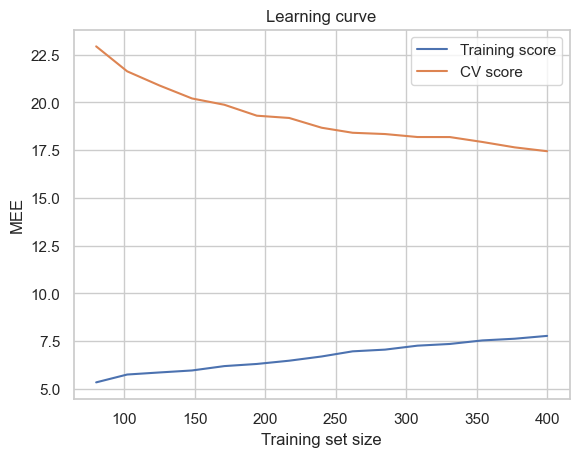

In [35]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=gs.scoring)

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

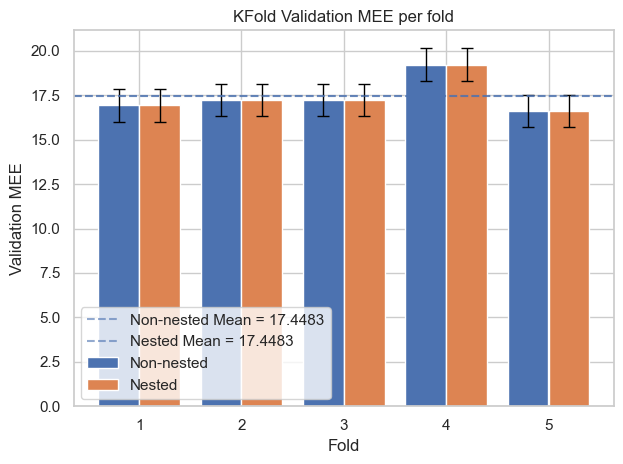

mee TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,7.806810,16.936386,9.129576,116.94%
2,8.016496,17.234268,9.217772,114.99%
3,7.813941,17.226448,9.412507,120.46%
4,7.475341,19.226307,11.750966,157.20%
5,7.762016,16.617956,8.855940,114.09%
MEAN,7.774921,17.448273,9.673352,124.74%
STD,0.194173,1.025654,1.178551,18.31%


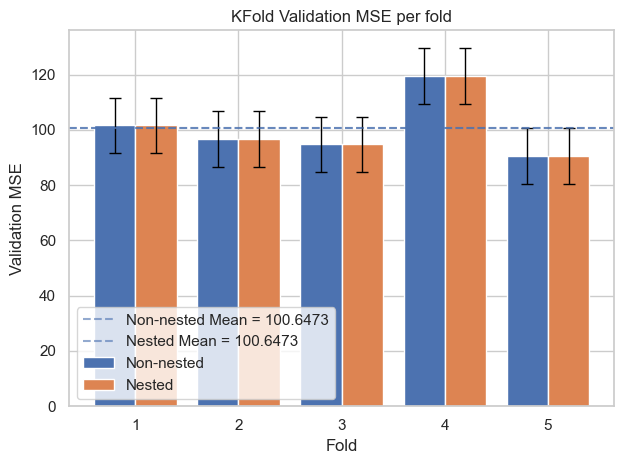

mse TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,21.727554,101.627235,79.899681,367.73%
2,23.304224,96.783646,73.479422,315.31%
3,22.134285,94.781525,72.647240,328.21%
4,20.852411,119.493706,98.641294,473.05%
5,21.405598,90.550476,69.144878,323.02%
MEAN,21.884814,100.647318,78.762503,361.46%
STD,0.921574,11.263084,11.771423,65.58%


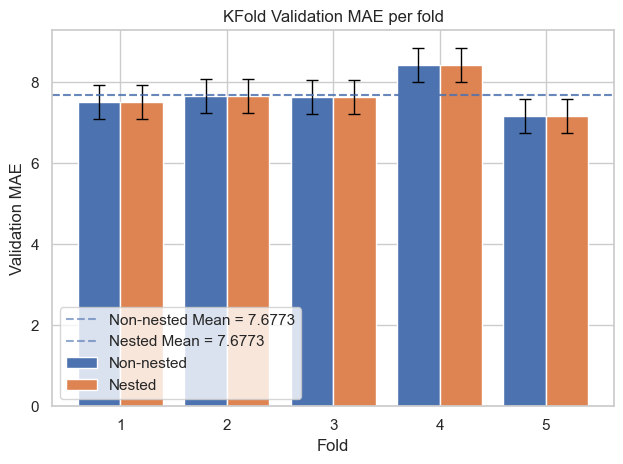

mae TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,3.456592,7.509850,4.053258,117.26%
2,3.551797,7.658602,4.106805,115.63%
3,3.422894,7.632256,4.209362,122.98%
4,3.272137,8.424527,5.152390,157.46%
5,3.440280,7.161308,3.721027,108.16%
MEAN,3.428740,7.677308,4.248568,124.30%
STD,0.100760,0.462335,0.537348,19.28%


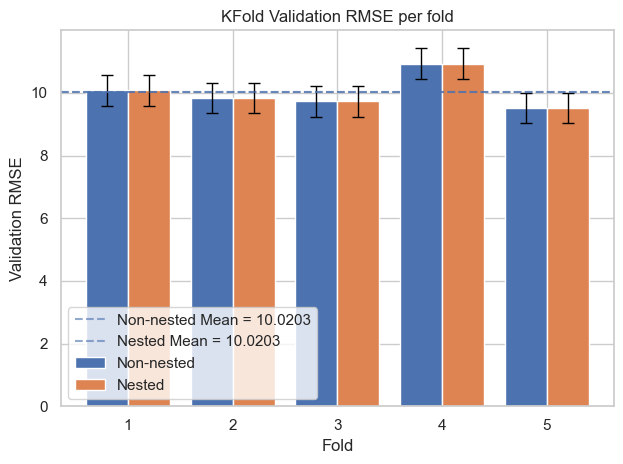

rmse TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,4.661282,10.081033,5.419751,116.27%
2,4.827445,9.837868,5.010423,103.79%
3,4.704709,9.735580,5.030872,106.93%
4,4.566444,10.931318,6.364874,139.38%
5,4.626618,9.515801,4.889183,105.68%
MEAN,4.677300,10.020320,5.343020,114.41%
STD,0.097991,0.548294,0.605000,14.76%


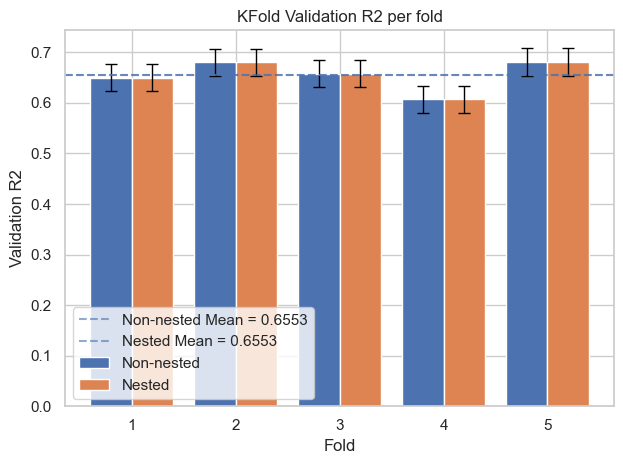

r2 TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,0.927377,0.650035,-0.277342,29.91%
2,0.921608,0.680454,-0.241153,26.17%
3,0.926565,0.657942,-0.268623,28.99%
4,0.929642,0.606903,-0.322738,34.72%
5,0.929111,0.680973,-0.248137,26.71%
MEAN,0.926860,0.655262,-0.271599,29.30%
STD,0.003192,0.030285,0.032150,3.40%


In [42]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(kf_result,"Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric} TR vs VL from KFold Nested results")
    display(cr.kfold_regression_table(nested_result, use=metric))

<h3>Bootstrap Variance</h3>

In [37]:
importlib.reload(cr)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(nested_runner, X_tr, y_tr, samples, metrics_dict, bootstrap_params=bootstrap_params)


In [38]:
cr.aggregate_scores(bootstrap_scores)

,metric,means,stds
0,rmse,12.31,0.46
1,r2,0.49,0.03
2,mse,151.77,11.33
3,mee,21.29,0.81
4,mae,9.26,0.38


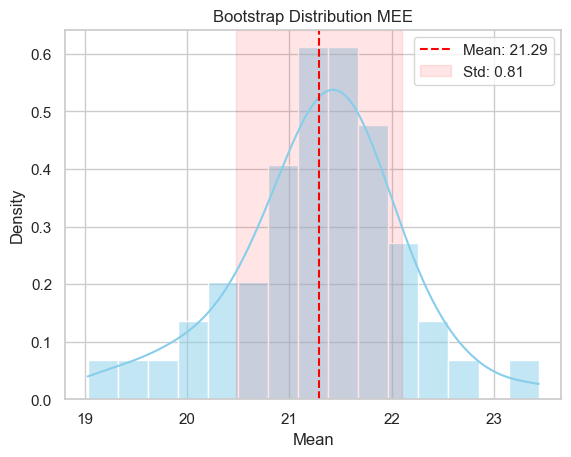

In [39]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title="Bootstrap Distribution MEE")

<h2>Test predictions</h2>
<hr/>

In [40]:
unfitted_model = runner.new_model()
fitted_model = runner.fit(unfitted_model, X_tr, y_tr)
y_pred = runner.predict(fitted_model, X_ts)

In [41]:
print(y_pred)

[[-1.6775169e+00 -2.0437698e+00  2.0170441e+00 -1.2453800e+01]
 [ 2.8324585e+00 -1.0611084e+01 -3.8077408e+01  1.4743248e+01]
 [-4.0720739e+00 -2.2500563e+00  2.5310755e-02  5.4710321e+00]
 ...
 [-1.0130135e+01  1.3044361e+01  2.2212772e+01 -7.3889847e+00]
 [ 1.6627747e+01  1.4378212e+01 -3.2589737e+01  1.0686317e+01]
 [ 6.8806839e-01 -1.0389748e+00  3.1597481e+00 -7.2684250e+00]]


<hr/>